In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/hetanshwaghela1/immunopath-sample-patches/sample_patch_1.jpg
/kaggle/input/datasets/hetanshwaghela1/immunopath-sample-patches/sample_patch_6.jpg
/kaggle/input/datasets/hetanshwaghela1/immunopath-sample-patches/sample_patch_4.jpg
/kaggle/input/datasets/hetanshwaghela1/immunopath-sample-patches/sample_patch_5.jpg
/kaggle/input/datasets/hetanshwaghela1/immunopath-sample-patches/sample_patch_7.jpg
/kaggle/input/datasets/hetanshwaghela1/immunopath-sample-patches/sample_patch_2.jpg
/kaggle/input/datasets/hetanshwaghela1/immunopath-sample-patches/sample_patch_3.jpg
/kaggle/input/datasets/hetanshwaghela1/immunopath-sample-patches/sample_patch_8.jpg
/kaggle/input/datasets/hetanshwaghela1/immunopath-sample-patches/metadata.json
/kaggle/input/datasets/hetanshwaghela1/immunopath-sample-patches/sample_patch_9.jpg
/kaggle/input/datasets/hetanshwaghela1/immunopath-sample-patches/sample_patch_10.jpg


In [2]:
import subprocess, os

subprocess.run([
    "pip", "install", "-q", "--upgrade",
    "transformers>=4.50.0",
    "accelerate>=0.34.0",
    "peft>=0.12.0",
    "bitsandbytes>=0.44.0",
], check=True)

import torch
print(f"PyTorch: {torch.__version__}")
if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    gpu_mem = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"GPU: {gpu_name} ({gpu_mem:.1f} GB)")
else:
    print("No GPU — this notebook requires GPU acceleration")

# HuggingFace auth (needed for gated MedGemma model)
from huggingface_hub import login
try:
    from kaggle_secrets import UserSecretsClient
    login(token=UserSecretsClient().get_secret("HF_TOKEN"))
    print("HuggingFace login (Kaggle secret)")
except Exception:
    try:
        from google.colab import userdata
        login(token=userdata.get('HF_TOKEN'))
        print("HuggingFace login (Colab secret)")
    except Exception:
        login()  # Interactive prompt

PyTorch: 2.9.0+cu126
GPU: Tesla T4 (15.6 GB)


In [3]:
subprocess.run(["pip", "install", "-q", "pillow<12.0", "--force-reinstall"], check=True)

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.


CompletedProcess(args=['pip', 'install', '-q', 'pillow<12.0', '--force-reinstall'], returncode=0)

In [4]:

from transformers import AutoProcessor, AutoModelForImageTextToText, BitsAndBytesConfig
from peft import PeftModel

MODEL_ID = "google/medgemma-1.5-4b-it"
ADAPTER_REPO = "hetanshwaghela/immunopath-medgemma-v2"

print(f"Loading base model: {MODEL_ID} (4-bit quantized)")
processor = AutoProcessor.from_pretrained(MODEL_ID)

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)

base_model = AutoModelForImageTextToText.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.bfloat16,
    device_map="auto",
    quantization_config=bnb_config,
)

print(f"Loading LoRA adapters from: {ADAPTER_REPO}")
model = PeftModel.from_pretrained(base_model, ADAPTER_REPO)
model.eval()

vram = torch.cuda.memory_allocated() / 1e9
print(f"✅ Fine-tuned model loaded — VRAM: {vram:.2f} GB")


Loading base model: google/medgemma-1.5-4b-it (4-bit quantized)


The image processor of type `Gemma3ImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 
`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/883 [00:00<?, ?it/s]

Loading LoRA adapters from: hetanshwaghela/immunopath-medgemma-v2


/usr/local/lib/python3.12/dist-packages/peft/tuners/tuners_utils.py:1225: UserWarning: Model has `tie_word_embeddings=True` and a tied layer is part of the adapter, but `ensure_weight_tying` is not set to True. This can lead to complications, for example when merging the adapter or converting your model to formats other than safetensors. Check the discussion here: https://github.com/huggingface/peft/issues/2777
  warnings.warn(msg)


✅ Fine-tuned model loaded — VRAM: 0.16 GB


Found 10 real patches, using 8
  sample_patch_1.jpg: (512, 512)


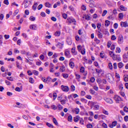

  sample_patch_6.jpg: (512, 512)


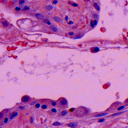

  sample_patch_4.jpg: (512, 512)


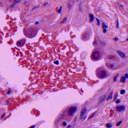

  sample_patch_5.jpg: (512, 512)


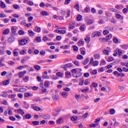

In [6]:
from PIL import Image
import numpy as np
import json

SAMPLE_PATCHES_DIR = "/tmp/immunopath_demo_patches"
os.makedirs(SAMPLE_PATCHES_DIR, exist_ok=True)

# Check if user uploaded real patches
KAGGLE_DATASET_PATH = "/kaggle/input/datasets/hetanshwaghela1/immunopath-sample-patches"
real_patches = []
if os.path.exists(KAGGLE_DATASET_PATH):
    for root, dirs, files in os.walk(KAGGLE_DATASET_PATH):
        for f in files:
            if f.lower().endswith(('.jpg', '.jpeg', '.png')):
                real_patches.append(os.path.join(root, f))

if real_patches:
    patch_paths = real_patches[:8]
    print(f"Found {len(real_patches)} real patches, using {len(patch_paths)}")


# Show patches
from IPython.display import display
for p in patch_paths[:4]:
    img = Image.open(p)
    print(f"  {os.path.basename(p)}: {img.size}")
    display(img.resize((128, 128)))

In [7]:
PROMPT = """You are a computational pathology AI analyzing H&E-stained histopathology patches.

Analyze these tissue patches and predict the tumor immune microenvironment profile.

Return a JSON object with exactly these fields:
{
  "cd274_expression": "high" or "low",
  "msi_status": "MSI-H" or "MSS",
  "tme_subtype": "IE", "IE/F", "F", or "D",
  "til_fraction": float between 0.0 and 1.0,
  "til_density": "low", "moderate", or "high",
  "immune_phenotype": "inflamed", "excluded", or "desert",
  "cd8_infiltration": "low", "moderate", or "high",
  "immune_score": float between 0.0 and 1.0
}

Return ONLY the JSON object, no other text."""

print("Prompt ready ")
print(f"Prompt length: {len(PROMPT)} chars")

Prompt ready 
Prompt length: 629 chars


In [10]:
from concurrent.futures import ThreadPoolExecutor
import time

def load_images(paths, max_patches=8):
    """Load and validate patch images."""
    def _load(p):
        try:
            return Image.open(p).convert("RGB")
        except Exception:
            return None
    paths = paths[:max_patches]
    with ThreadPoolExecutor(max_workers=4) as pool:
        results = list(pool.map(_load, paths))
    return [img for img in results if img is not None]


def run_medgemma_inference(images, prompt, model, processor, max_new_tokens=600):
    """Run fine-tuned MedGemma inference on patch images."""
    content = [{"type": "image", "image": img} for img in images]
    content.append({"type": "text", "text": prompt})
    messages = [{"role": "user", "content": content}]

    inputs = processor.apply_chat_template(
        messages, add_generation_prompt=True,
        tokenize=True, return_dict=True, return_tensors="pt",
    )
    inputs = {
        k: v.to(model.device, dtype=torch.bfloat16) if v.is_floating_point()
        else v.to(model.device)
        for k, v in inputs.items()
        if torch.is_tensor(v)
    }
    input_len = inputs["input_ids"].shape[-1]

    with torch.inference_mode():
        output_ids = model.generate(
            **inputs, max_new_tokens=max_new_tokens,
            do_sample=False, use_cache=True,
        )
    generated = output_ids[0][input_len:]
    raw = processor.decode(generated, skip_special_tokens=True).strip()
    return raw


def parse_json_output(raw_text):
    """Extract JSON from model output."""
    clean = raw_text
    if "```json" in clean:
        clean = clean.split("```json")[1].split("```")[0]
    elif "```" in clean:
        clean = clean.split("```")[1].split("```")[0]
    start = clean.find("{")
    end = clean.rfind("}") + 1
    if start != -1 and end > start:
        return json.loads(clean[start:end])
    return None


# Run inference
images = load_images(patch_paths)
print(f"Loaded {len(images)} images")
print("Running TPU sequential inference...\n")

all_outputs = []
total_start = time.time()

for idx, img in enumerate(images):
    print(f"\n--- Image {idx+1}/{len(images)} ---")

    t0 = time.time()
    raw_output = run_medgemma_inference(
        [img],        # single image
        PROMPT,
        model,
        processor,
        max_new_tokens=400  # reduce if TPU OOM
    )
    elapsed = time.time() - t0

    print(f"Inference time: {elapsed:.2f}s")
    print(raw_output[:500])  # avoid printing huge text

    all_outputs.append(raw_output)

print(f"\nTotal time: {time.time() - total_start:.2f}s")



Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.


Loaded 8 images
Running TPU sequential inference...


--- Image 1/8 ---


Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.


Inference time: 19.22s
{"cd274_expression": "low", "msi_status": "MSS", "tme_subtype": "D", "til_fraction": 0.384, "til_density": "moderate", "immune_phenotype": "desert", "cd8_infiltration": "moderate", "immune_score": 0.406}

--- Image 2/8 ---


Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.


...

Inference time: 19.41s
{"cd274_expression": "low", "msi_status": "MSS", "tme_subtype": "D", "til_fraction": 0.384, "til_density": "moderate", "immune_phenotype": "desert", "cd8_infiltration": "moderate", "immune_score": 0.416}

--- Image 6/8 ---


Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.


Inference time: 19.68s
{"cd274_expression": "low", "msi_status": "MSS", "tme_subtype": "D", "til_fraction": 0.388, "til_density": "moderate", "immune_phenotype": "desert", "cd8_infiltration": "moderate", "immune_score": 0.402}

--- Image 7/8 ---


Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.


Inference time: 19.44s
{"cd274_expression": "low", "msi_status": "MSS", "tme_subtype": "D", "til_fraction": 0.384, "til_density": "moderate", "immune_phenotype": "desert", "cd8_infiltration": "moderate", "immune_score": 0.406}

--- Image 8/8 ---
Inference time: 19.27s
{"cd274_expression": "low", "msi_status": "MSS", "tme_subtype": "D", "til_fraction": 0.383, "til_density": "moderate", "immune_phenotype": "desert", "cd8_infiltration": "moderate", "immune_score": 0.416}

Total time: 155.36s


In [11]:
parsed = parse_json_output(raw_output)

REQUIRED_KEYS = [
    "cd274_expression", "msi_status", "tme_subtype", "til_fraction",
    "til_density", "immune_phenotype", "cd8_infiltration", "immune_score",
]

if parsed:
    print("JSON parsed successfully!")
    print(f"\n{'='*60}")
    print("  IMMUNE PROFILE (MedGemma Fine-Tuned)")
    print(f"{'='*60}")

    present = sum(1 for k in REQUIRED_KEYS if k in parsed)
    print(f"\n  Schema compliance: {present}/{len(REQUIRED_KEYS)} fields present")

    for k in REQUIRED_KEYS:
        v = parsed.get(k, "MISSING")
        print(f"    {k:25s}: {v}")

    print(f"\n  All 8 fields present: {'YES' if present == 8 else 'NO'}")
else:
    print("Failed to parse JSON from model output")
    print(f"Raw output:\n{raw_output}")

JSON parsed successfully!

  IMMUNE PROFILE (MedGemma Fine-Tuned)

  Schema compliance: 8/8 fields present
    cd274_expression         : low
    msi_status               : MSS
    tme_subtype              : D
    til_fraction             : 0.383
    til_density              : moderate
    immune_phenotype         : desert
    cd8_infiltration         : moderate
    immune_score             : 0.416

  All 8 fields present: YES


In [12]:
# Inline guideline engine (simplified from scripts/guideline_engine.py)
def get_recommendation(immune_profile):
    """Rule-based NCCN-aligned treatment recommendation."""
    msi = immune_profile.get("msi_status", "unknown").upper()
    cd274 = immune_profile.get("cd274_expression", "unknown").lower()
    phenotype = immune_profile.get("immune_phenotype", "unknown").lower()

    SAFETY = ("AI-generated research prototype. NOT for clinical decisions. "
              "All recommendations require confirmatory molecular testing.")

    if msi == "MSI-H":
        return {
            "primary_drug": "pembrolizumab",
            "regimen": "Pembrolizumab monotherapy (MSI-H indication)",
            "confidence": "high",
            "evidence": ["KEYNOTE-158 (FDA pan-tumor MSI-H approval)"],
            "confirmatory_tests": ["MSI PCR/NGS or IHC (dMMR)"],
            "safety": SAFETY,
        }
    elif cd274 == "high" and phenotype == "inflamed":
        return {
            "primary_drug": "anti-PD-1/PD-L1 agent",
            "regimen": "Consider ICI-based regimen (CONDITIONAL)",
            "confidence": "conditional",
            "evidence": ["CD274 mRNA proxy correlates with IHC (r²=0.65-0.81)"],
            "confirmatory_tests": ["PD-L1 IHC (22C3 or SP263)", "Driver mutation testing"],
            "safety": SAFETY,
        }
    else:
        return {
            "primary_drug": None,
            "regimen": "Standard-of-care workup recommended",
            "confidence": "low",
            "evidence": [],
            "confirmatory_tests": ["PD-L1 IHC", "MSI/dMMR testing", "Driver mutation panel"],
            "safety": SAFETY,
        }

rec = {}
if parsed:
    rec = get_recommendation(parsed)
    print(f"\n{'='*60}")
    print("  TREATMENT RECOMMENDATION (Guideline Engine)")
    print(f"{'='*60}")
    print(f"    Primary Drug:   {rec['primary_drug'] or 'None (standard workup)'}")
    print(f"    Regimen:        {rec['regimen']}")
    print(f"    Confidence:     {rec['confidence']}")
    if rec['evidence']:
        print(f"    Evidence:       {', '.join(rec['evidence'])}")
    if rec['confirmatory_tests']:
        print(f"    Tests needed:   {', '.join(rec['confirmatory_tests'])}")
    print(f"\n    {rec['safety']}")
else:
    print("\nSkipped — no immune profile parsed")


  TREATMENT RECOMMENDATION (Guideline Engine)
    Primary Drug:   None (standard workup)
    Regimen:        Standard-of-care workup recommended
    Confidence:     low
    Tests needed:   PD-L1 IHC, MSI/dMMR testing, Driver mutation panel

    AI-generated research prototype. NOT for clinical decisions. All recommendations require confirmatory molecular testing.


In [13]:
result = {
    "model": MODEL_ID,
    "adapter": ADAPTER_REPO,
    "immune_profile": parsed,
    "recommendation": rec if rec else {},
    "raw_output": raw_output,
    "inference_time_s": round(elapsed, 2),
    "n_images": len(images),
    "gpu": torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU",
    "vram_gb": round(torch.cuda.memory_allocated() / 1e9, 2),
    "json_valid": parsed is not None,
    "schema_compliant": parsed is not None and all(
        k in parsed for k in REQUIRED_KEYS
    ),
}

output_path = "/tmp/immunopath_finetuned_result.json"
with open(output_path, "w") as f:
    json.dump(result, f, indent=2, default=str)

print(f"\n Results saved to {output_path}")
print(json.dumps(result, indent=2, default=str))


 Results saved to /tmp/immunopath_finetuned_result.json
{
  "model": "google/medgemma-1.5-4b-it",
  "adapter": "hetanshwaghela/immunopath-medgemma-v2",
  "immune_profile": {
    "cd274_expression": "low",
    "msi_status": "MSS",
    "tme_subtype": "D",
    "til_fraction": 0.383,
    "til_density": "moderate",
    "immune_phenotype": "desert",
    "cd8_infiltration": "moderate",
    "immune_score": 0.416
  },
  "recommendation": {
    "primary_drug": null,
    "regimen": "Standard-of-care workup recommended",
    "confidence": "low",
    "evidence": [],
    "confirmatory_tests": [
      "PD-L1 IHC",
      "MSI/dMMR testing",
      "Driver mutation panel"
    ],
    "safety": "AI-generated research prototype. NOT for clinical decisions. All recommendations require confirmatory molecular testing."
  },
  "raw_output": "{\"cd274_expression\": \"low\", \"msi_status\": \"MSS\", \"tme_subtype\": \"D\", \"til_fraction\": 0.383, \"til_density\": \"moderate\", \"immune_phenotype\": \"desert\",